**La columna violations tiene informacion interesante para extraer**

# Analisis de columna volations

Comenzaremos importando las librerias que se requieren para el analis

In [16]:
import os
import pandas as pd
import boto3
import pickle
import matplotlib.pyplot as plt
import plotly.express as px
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Traemos la informacion ya limpia para hacer analisis

In [18]:
import os
import pickle
import boto3
from dotenv import load_dotenv

# Cargar variables de entorno
load_dotenv()

# Configurar cliente de S3
s3_client = boto3.client(
    's3',
    aws_access_key_id=os.getenv('NOTEBOOK_ACCESS_KEY'),
    aws_secret_access_key=os.getenv('NOTEBOOK_ACCESS_KEY_SECRET')
)

bucket_name = 'chicago-inspections-analytics'
ingesta_inicial_key = 'ingesta/inicial/inspecciones-historicas-2024-11-12T19-51-57.pkl'
ingesta_consecutivas_folder = 'ingesta/consecutiva/'

# Variable para llevar el total de los datos descargados
total_bytes_descargados = 0

# Función para cargar un archivo desde S3 y convertirlo en DataFrame
def cargar_ingesta_s3(s3_client, bucket, key):
    global total_bytes_descargados
    file_obj = s3_client.get_object(Bucket=bucket, Key=key)
    file_data = file_obj['Body'].read()
    total_bytes_descargados += len(file_data)  # Acumulando el tamaño del archivo descargado
    return pickle.loads(file_data)

# Cargar ingesta inicial
df_total = cargar_ingesta_s3(s3_client, bucket_name, ingesta_inicial_key)
print("✅ Ingesta inicial cargada exitosamente.")

# Listar los archivos en la carpeta de ingestas consecutivas
response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=ingesta_consecutivas_folder)

# Verificar si hay archivos en la carpeta
if 'Contents' in response:
    for obj in response['Contents']:
        file_key = obj['Key']
        
        # Saltar si el archivo es un folder
        if file_key.endswith('/'):
            continue
        
        print(f"📥 Cargando ingesta consecutiva: {file_key}")
        
        # Cargar el nuevo DataFrame e ir concatenando
        df_nueva = cargar_ingesta_s3(s3_client, bucket_name, file_key)
        df_total = pd.concat([df_total, df_nueva], ignore_index=True)

    print("✅ Todas las ingestas consecutivas han sido cargadas y concatenadas.")
else:
    print("⚠️ No se encontraron ingestas consecutivas en la carpeta.")

# Mostrar tamaño final del DataFrame y el total de datos descargados
print(f"📊 Total de registros después de concatenar: {df_total.shape[0]}")
print(f"📦 Total de datos descargados: {total_bytes_descargados / (1024**2):.2f} MB")  # Convertir a MB


✅ Ingesta inicial cargada exitosamente.
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-53-54.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-54-55.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-55-57.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-56-59.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-58-01.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T19-59-03.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T20-00-05.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T20-01-07.pkl
📥 Cargando ingesta consecutiva: ingesta/consecutiva/inspecciones-consecutivas-2024-11-12T20-02-09.pkl
📥 Cargando ingesta consecutiva: ingesta/co

De acuerdo al sitio oficial de chicago inspections hubo cambios a partir de 2018-07-01 separamos

In [ ]:
 
# Mostrar ejemplos de cada grupo
print("Ejemplo antes del cambio:")
print(antes_cambio.sample(3))  # Muestra 3 ejemplos aleatorios

print("\nEjemplo después del cambio:")
print(despues_cambio.sample(3))  # Muestra 3 ejemplos aleatorios


Ejemplo antes del cambio:
       inspection_id          dba_name          aka_name license_  \
111242       1566880     PUDGY'S PIZZA     PUDGY'S PIZZA    59269   
32490         634860  M & M  FOOD MART  M & M  FOOD MART  2120545   
80181        1402001   PATIO BEEF, INC        PATIO BEEF  2279587   

        facility_type           risk                 address     city state  \
111242     Restaurant  Risk 1 (High)  13460 S BALTIMORE AVE   CHICAGO    IL   
32490   Grocery Store   Risk 3 (Low)     7073 N WESTERN AVE   CHICAGO    IL   
80181      Restaurant  Risk 1 (High)        6022 N BROADWAY   CHICAGO    IL   

          zip inspection_date inspection_type results           latitude  \
111242  60633      2015-08-28         Canvass    Pass  41.65017306247574   
32490   60645      2011-10-05         License    Fail  42.01076851593425   
80181   60660      2014-03-14         Canvass    Pass  41.99164923315811   

                 longitude  \
111242  -87.54730766219589   
32490   -87.690

Solo conservamos estas columnas

In [20]:
df_total = df_total[['violations', 'inspection_date', 'inspection_id','results']]
df_total.head()


violations  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [21]:
df_total = df_total.dropna(subset=['violations'])

In [22]:
df_total.value_counts()

violations                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

AL analizar la columna violations obsevamos una estructura algo parecida a esto:
1. codigo 
2. categoria
3. comentarios
4. Metadatos(aun no descifro como esta estructurado esto).



Por lo tanto separaremos la columna *violations* y se convertira en un nuevo dataframe con las 4 columnas mencionadas anteriormente.
aparentemente el separador de cada violacion es |. Entonces tenemos que **por cada inspeccion podemos tener muchas violaciones** osea una relacion de uno a muchos. El siguiente script se encarara de hacer las transformaciones necesarias.

In [25]:
# Función para procesar una fila de la columna 'violations'
def procesar_violations(violations_text):
    if not isinstance(violations_text, str):  # Verifica que sea texto válido
        return []  # Retorna vacío si no es string

    violations = violations_text.split("|")  # Dividir violaciones por el delimitador
    structured_data = []

    for violation in violations:
        # Extraer cada componente usando expresiones regulares
        codigo_match = re.match(r"^\d+", violation.strip())  # Número de código al inicio
        categoria_match = re.search(r"^\d+\.\s(.+?)\s- Comments:", violation)  # Categoría
        comentarios_match = re.search(r"- Comments:(.+?)\(", violation)  # Comentarios antes del primer paréntesis
        metadatos_match = re.findall(r"\(([^)]+)\)", violation)  # Todo lo que está entre paréntesis

        # Agregar datos estructurados
        structured_data.append({
            "Código": codigo_match.group() if codigo_match else None,
            "Categoría": categoria_match.group(1).strip() if categoria_match else None,
            "Comentarios": comentarios_match.group(1).strip() if comentarios_match else None,
            "Metadatos": "; ".join(metadatos_match) if metadatos_match else None
        })

    return structured_data

# Iterar sobre cada fila y procesar
resultado = []
for _, row in df_total.iterrows():
    # Procesar la columna 'violations'
    registros = procesar_violations(row.get('violations', ''))  # Maneja valores no válidos
    # Agregar inspection_id para la relación 1 a muchos
    for registro in registros:
        registro["inspection_id"] = row['inspection_id']  # Vincular con el identificador único
        registro["results"] = row['results']  # Agregar el valor de 'results' a cada registro
        resultado.append(registro)

# Convertir los resultados en un DataFrame estructurado
df_procesado = pd.DataFrame(resultado)


In [26]:
df_procesado.head(20)

,Código,Categoría,Comentarios,Metadatos,inspection_id,results
0,18,"NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS PROTECTED/RODENT PROOFED, A WRITTEN LOG SHALL BE MAINTAINED AVAILABLE TO THE INSPECTORS",None,None,104236,Fail
1,19,None,None,None,104236,Fail
2,32,None,None,None,104236,Fail
3,33,None,None,None,104236,Fail
4,34,None,None,None,104236,Fail
5,35,None,None,None,104236,Fail
6,36,None,None,None,104236,Fail
7,37,None,None,None,104236,Fail
8,38,None,None,None,104236,Fail
9,39,None,None,None,104236,Fail


Ahora investiguemos las metricas de este dataset

In [27]:
df_procesado.count()

Código           921475
Categoría        202939
Comentarios      136066
Metadatos        152568
inspection_id    921475
results          921475
dtype: int64

No esta normalizado investiguemos mas

In [30]:
# Rellenar valores faltantes con un valor predeterminado
df_procesado.fillna({'Categoría': 'Desconocido', 'Comentarios': 'No disponible', 'Metadatos': 'N/A'}, inplace=True)
print(df_procesado.count())


Código           921475
Categoría        921475
Comentarios      921475
Metadatos        921475
inspection_id    921475
results          921475
dtype: int64


NOrmalizado

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/home/antonio/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
11519/11519 ━━━━━━━━━━━━━━━━━━━━ 397s 34ms/step - AUC: 0.7083 - accuracy: 0.6579 - loss: 0.5893 - val_AUC: 0.7203 - val_accuracy: 0.6791 - val_loss: 0.5760
Epoch 2/5
11519/11519 ━━━━━━━━━━━━━━━━━━━━ 76s 7ms/step - AUC: 0.7233 - accuracy: 0.6771 - loss: 0.5779 - val_AUC: 0.7199 - val_accuracy: 0.6420 - val_loss: 0.5918
Epoch 3/5
11519/11519 ━━━━━━━━━━━━━━━━━━━━ 67s 6ms/step - AUC: 0.7329 - accuracy: 0.6833 - loss: 0.5701 - val_AUC: 0.7170 - val_accuracy: 0.6640 - val_loss: 0.5858
Epoch 4/5
11519/11519 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - AUC: 0.7414 - accuracy: 0.6926 - loss: 0.5607 - val_AUC: 0.7143 - val_accuracy: 0.6696 - val_loss: 0.5972
Epoch 5/5
11519/11519 ━━━━━━━━━━━━━━━━━━━━ 59s 5ms/step - AUC: 0.7461 - accuracy: 0.6917 - loss: 0.5549 - val_AUC: 0.7138 - val_accuracy: 0.6730 - val_loss: 0.5950
5760/5760 ━━━━━━━━━━━━━━━━━━━━ 74s 13ms/step - AUC: 0.7143 - accuracy: 0.6735 - loss: 0.5951
Pérdida: 0.5949823260307312
Precisión: 0.6730188131332397
AUC: 0.7138037085533142
576

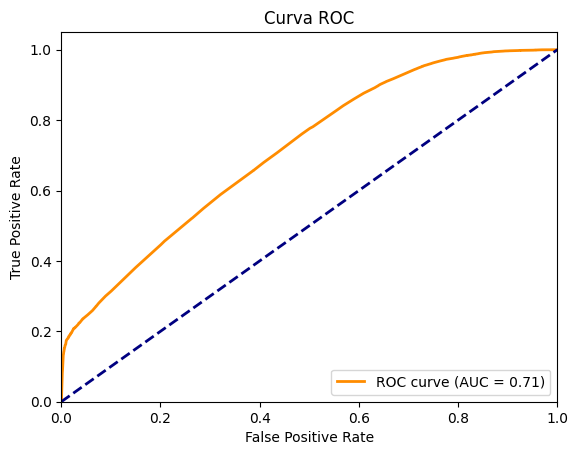

Predicciones: [[0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]]


In [37]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils import class_weight
# Verificar si TensorFlow puede acceder a una GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU disponible: {gpus}')
    # Configurar la memoria para que no se acapare toda la GPU (opcional)
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No se encontró GPU, utilizando CPU")

# Supongamos que 'df_procesado' es tu dataframe y ya tienes la columna 'Comentarios' y 'results'
# Vamos a separar las columnas de texto (Comentarios) y la columna objetivo (results)
X = df_procesado[['Comentarios', 'Código', 'Categoría', 'Metadatos', 'inspection_id']]  # Agregamos las columnas extra
y = df_procesado['results'].map({'Fail': 0, 'Pass': 1, 'Pass w/ Conditions': 1}).fillna(0)

# Preprocesar los datos
# Usamos un ColumnTransformer para aplicar diferentes transformaciones a las diferentes columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('comentarios', TfidfVectorizer(max_features=10000), 'Comentarios'),  # Vectorización TF-IDF para 'Comentarios'
        ('codigo', OneHotEncoder(handle_unknown='ignore'), ['Código']),  # Codificación One-Hot para 'Código' (ahora categórica)        ('categoria', OneHotEncoder(), ['Categoría']),  # Codificación One-Hot para 'Categoría'        ('metadatos', StandardScaler(), ['Metadatos']),  # Escalado de 'Metadatos' si es numérico
        ('metadatos', OneHotEncoder(handle_unknown='ignore'), ['Metadatos']),  # Codificación One-Hot para 'Metadatos' (categórica)
        ('categoria', OneHotEncoder(handle_unknown='ignore'), ['Categoría']),
    ])



# Divide los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicamos el preprocesador a los datos
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Definir el modelo
model = Sequential()

# Capa de entrada (input layer)
model.add(Dense(512, input_dim=X_train_processed.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Regularización para evitar overfitting

# Capa oculta
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

# Capa de salida
model.add(Dense(1, activation='sigmoid'))  # Activación sigmoide para clasificación binaria

# Compilar el modelo
model.compile(loss='binary_crossentropy',  # Usamos binary_crossentropy para clasificación binaria
              optimizer=Adam(),  # Optimizador Adam
              metrics=['accuracy', 'AUC'])  # AÑADIDO AUC como métrica
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# Entrenar el modelo
history = model.fit(X_train_processed, y_train, class_weight=dict(enumerate(class_weights)),epochs=5, batch_size=64, validation_data=(X_test_processed, y_test))

# Evaluar el modelo en el conjunto de prueba
loss, accuracy, auc_value = model.evaluate(X_test_processed, y_test)
print(f'Pérdida: {loss}')
print(f'Precisión: {accuracy}')
print(f'AUC: {auc_value}')

# Realizar predicciones en el conjunto de prueba (obtener probabilidades)
predicciones_prob = model.predict(X_test_processed)

# Calcular la curva ROC y el AUC
fpr, tpr, _ = roc_curve(y_test, predicciones_prob)
roc_auc = auc(fpr, tpr)

# Visualizar la curva ROC



plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

# Mostrar algunas predicciones
predicciones = (predicciones_prob > 0.5).astype(int)  # Convertir probabilidades a 0 o 1
print(f'Predicciones: {predicciones[:10]}')



Best threshold: 0.5076656341552734


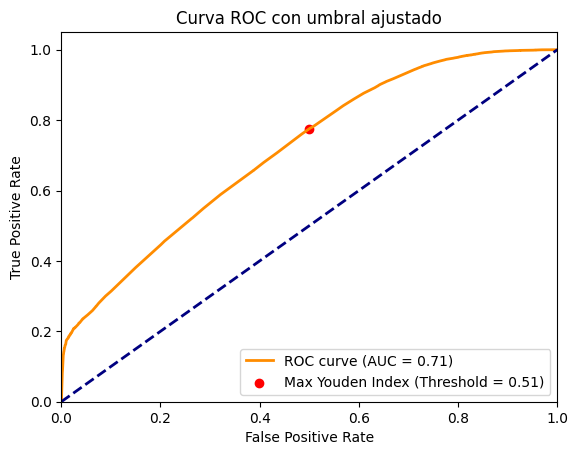

In [39]:
from sklearn.metrics import roc_curve

# Calcular los valores de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, predicciones_prob)

# Calcular el índice de Youden para cada umbral
youden_index = tpr - fpr

# Elegir el umbral que maximiza el índice de Youden
best_threshold = thresholds[np.argmax(youden_index)]

print(f'Best threshold: {best_threshold}')

# Aplicar el umbral óptimo
predicciones_optimas = (predicciones_prob > best_threshold).astype(int)


# Graficar la curva ROC con diferentes umbrales
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Marcar el mejor umbral
plt.scatter(fpr[np.argmax(youden_index)], tpr[np.argmax(youden_index)], color='red', label=f'Max Youden Index (Threshold = {best_threshold:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC con umbral ajustado')
plt.legend(loc='lower right')
plt.show()


In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, predicciones_optimas)
recall = recall_score(y_test, predicciones_optimas)
f1 = f1_score(y_test, predicciones_optimas)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')


Precision: 0.7213048601359094
Recall: 0.7757688334910205
F1 Score: 0.7475461392730633


In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.utils import class_weight

# Supongamos que 'df_procesado' es tu dataframe con las columnas 'Comentarios' y 'results'
# Y que ya tienes una columna 'Comentarios' y 'results'
X = df_procesado[['Comentarios', 'Código', 'Categoría', 'Metadatos', 'inspection_id']]  # Puedes agregar más columnas según sea necesario
y = df_procesado['results'].map({'Fail': 0, 'Pass': 1, 'Pass w/ Conditions': 1}).fillna(0)

# Preprocesar los datos (aplicar transformación TF-IDF para 'Comentarios' y codificación para otras columnas)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('comentarios', TfidfVectorizer(max_features=10000), 'Comentarios'),
        ('codigo', OneHotEncoder(handle_unknown='ignore'), ['Código']),
        ('categoria', OneHotEncoder(handle_unknown='ignore'), ['Categoría']),
        ('metadatos', OneHotEncoder(handle_unknown='ignore'), ['Metadatos']),
    ]
)

# Divide los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicamos el preprocesador a los datos
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Normalizar los datos (esto es importante para SVM)
scaler = StandardScaler(with_mean=False)  # SVM no requiere centrado, solo escalado
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Calcular los pesos de las clases si hay desbalance
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Definir el modelo SVM
model = SVC(kernel='rbf', class_weight=class_weights_dict, probability=True)  # SVM con kernel RBF y probabilidad para calcular AUC

# Entrenar el modelo
model.fit(X_train_scaled, y_train)

# Evaluar el modelo en el conjunto de prueba
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probabilidades para la clase positiva

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión: {accuracy}')

# Calcular la curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Visualizar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

# Mostrar algunas predicciones
print(f'Predicciones (primeras 10): {y_pred[:10]}')


: 

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Supongamos que 'df_procesado' es tu dataframe con las columnas 'Comentarios' y 'results'
X = df_procesado[['Comentarios', 'Código', 'Categoría', 'Metadatos', 'inspection_id']]  
y = df_procesado['results'].map({'Fail': 0, 'Pass': 1, 'Pass w/ Conditions': 1}).fillna(0)

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('comentarios', TfidfVectorizer(max_features=10000), 'Comentarios'),
        ('codigo', OneHotEncoder(handle_unknown='ignore'), ['Código']),
        ('categoria', OneHotEncoder(handle_unknown='ignore'), ['Categoría']),
        ('metadatos', OneHotEncoder(handle_unknown='ignore'), ['Metadatos']),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Escalado de los datos
scaler = StandardScaler(with_mean=False) 
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Calcular los pesos de las clases si hay desbalance
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Modelo XGBoost
model_xgb = xgb.XGBClassifier(scale_pos_weight=class_weights_dict[1], n_estimators=100, random_state=42)

# Entrenamiento del modelo
model_xgb.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model_xgb.predict(X_test_scaled)
y_pred_prob = model_xgb.predict_proba(X_test_scaled)[:, 1]  # Probabilidades para la clase positiva

# Evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión: {accuracy}')

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Visualización
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost')
plt.legend(loc='lower right')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Supongamos que 'df_procesado' es tu dataframe con las columnas 'Comentarios' y 'results'
X = df_procesado[['Comentarios', 'Código', 'Categoría', 'Metadatos', 'inspection_id']]  
y = df_procesado['results'].map({'Fail': 0, 'Pass': 1, 'Pass w/ Conditions': 1}).fillna(0)

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('comentarios', TfidfVectorizer(max_features=10000), 'Comentarios'),
        ('codigo', OneHotEncoder(handle_unknown='ignore'), ['Código']),
        ('categoria', OneHotEncoder(handle_unknown='ignore'), ['Categoría']),
        ('metadatos', OneHotEncoder(handle_unknown='ignore'), ['Metadatos']),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Escalado de los datos
scaler = StandardScaler(with_mean=False) 
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Calcular los pesos de las clases si hay desbalance
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Modelo Random Forest
model_rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

# Entrenamiento del modelo
model_rf.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model_rf.predict(X_test_scaled)
y_pred_prob = model_rf.predict_proba(X_test_scaled)[:, 1]  # Probabilidades para la clase positiva

# Evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión: {accuracy}')

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Visualización
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np

# Supongamos que 'df_procesado' es tu dataframe con las columnas 'Comentarios' y 'results'
X = df_procesado[['Comentarios', 'Código', 'Categoría', 'Metadatos', 'inspection_id']]  
y = df_procesado['results'].map({'Fail': 0, 'Pass': 1, 'Pass w/ Conditions': 1}).fillna(0)

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('comentarios', TfidfVectorizer(max_features=10000), 'Comentarios'),
        ('codigo', OneHotEncoder(handle_unknown='ignore'), ['Código']),
        ('categoria', OneHotEncoder(handle_unknown='ignore'), ['Categoría']),
        ('metadatos', OneHotEncoder(handle_unknown='ignore'), ['Metadatos']),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Escalado de los datos
scaler = StandardScaler(with_mean=False) 
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Calcular los pesos de las clases si hay desbalance
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Definir el modelo Random Forest
model_rf = RandomForestClassifier(random_state=42)

# Definir el parámetro grid para GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árboles
    'max_depth': [10, 20, None],  # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10],  # Mínimo número de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4],  # Mínimo número de muestras para ser hoja
    'bootstrap': [True, False],  # Si se usa bootstrap para el muestreo
    'class_weight': ['balanced', None],  # Manejo del desbalanceo
}

# Configurar GridSearchCV
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Entrenamiento con GridSearchCV
grid_search.fit(X_train_scaled, y_train)

# Mejor modelo encontrado por GridSearchCV
best_rf = grid_search.best_estimator_

# Predicciones
y_pred = best_rf.predict(X_test_scaled)
y_pred_prob = best_rf.predict_proba(X_test_scaled)[:, 1]  # Probabilidades para la clase positiva

# Evaluación
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión: {accuracy}')

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Visualización de la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.show()

# Mejor combinación de hiperparámetros
print("Mejores parámetros encontrados: ", grid_search.best_params_)
